# Nonlinear Static Analysis

This example investigates analysis methods for nonlinear static analysis. 
Consider the shallow arch shown below (Clarke and Hancock, 1990).

![gallery_thumbnail](/_static/images/gallery/ClarkeHancock-b281f197.png)

This problem exhibits several critical points along the solution path,
and requires the use of a sophisticated algorithm to properly traverse these.
In this study, we will investigate how the OpenSees framework can be used to compose these algorithms.



In this notebook, the `Model` is created by the `arch_model` helper function:

In [1]:
import xara 
import numpy as np


def arch_model():
    # Define model parameters
    L      = 5000
    Rise   = 500
    Offset = 200

    # Define material parameters
    E = 200
    A = 1e4
    I = 1e8

    # Compute radius
    R  = Rise/2 + (2*L)**2/(8*Rise)
    th = 2*np.arcsin(L/R)

    #
    # Build the model
    #
    model = xara.Model(ndm=3, ndf=6)

    # Create nodes
    ne  = 10
    nen =  2             # nodes per element
    nn  = ne*(nen-1)+1
    mid = (nn+1)//2      # midpoint node

    for i, angle in enumerate(np.linspace(-th/2, th/2, nn)):
        tag = i + 1

        # Compute x and add offset if midpoint
        x = R*np.sin(angle)
        if tag == mid:
            x -= Offset

        # Compute y
        y = R*np.cos(angle) - R*np.cos(th/2)

        # create the node with coordinates (x, y, 0)
        model.node(tag, (x, y, 0))


    model.section("ElasticFrame", 1, A=A, E=E, Iy=I, Iz=I, J=2*I, G=E, Ay=A*100, Az=A*100)

    # Create elements
    model.geomTransf("Corotational02", 1, (0, 0, 1))
    for i in range(ne):
        tag   = i+1
        nodes = (i+1, i+2)
        model.element("ForceFrame", tag, nodes, section=1, transform=1, shear=0)


    model.fix( 1, (1, 1, 0, 1, 1, 0))
    model.fix(nn, (1, 1, 0, 1, 1, 0))
    for i in model.getNodeTags():
        model.fix(i, dof=3)

    # Create a load pattern that scales linearly
    model.pattern("Plain", 1, "Linear")

    # Add a nodal load to the pattern
    model.load(mid, (0.0, -1.0, 0.0, 0, 0, 0), pattern=1)


    model.system("BandGeneral", det=True)
#   model.system("Umfpack", det=True)

    # model.test("NormUnbalance", 1e-6, 25, 0)
    model.test("NormDispIncr", 1e-8, 25, 0)
    model.algorithm("Newton")
    model.analysis("Static")


    return model, mid

We'll also find the following imports convenient:

In [ ]:
import matplotlib.pyplot as plt

try:
    plt.style.use("typewriter") #("veux-web")
except:
    pass

## Solution Strategy

Our general strategy is implemented in the following function `solve()`.
This function adopts an incremental approach
where the load is applied in small steps of varying size. 
The arguments to the function are:

- `model`: a [`xara.Model`](https://xara.so/user/manual/model/model_class.html) instance
- `node` : an integer indicating which node to collect results from.

Both of these arguments will be supplied by the `arch_model` helper function mentioned
above.


In [3]:
def analyze(model, mid, increment, steps, dx, *args):
    # Initialize some variables
    xy = [[0,0]]      # Container to hold solution history (i.e., load factor and displacement at `node`)
    status = 0   # Convergence flag; Model.analyze() will return 0 if successful.

    # Configure the first load increment strategy; explained below
    increment(model, dx, *args)

    steps = 1000
    i = 0
    while  model.getTime() < 2000 and i < steps:
        i += 1
    # for step in range(steps):

        # 1. Perform Newton-Raphson iterations until convergence for 1 load
        #    increment
        status = model.analyze(1)

        # 2. Store the displacement and load factor
        xy.append([model.nodeDisp(mid, 2), model.getTime()])

        # 3. If the iterations failed, try cutting
        #    the initial increment in half
        if status != 0:
            dx /= 2
            increment(model, dx, *args)

    return np.array(xy).T

In [4]:
def create_figure():
    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(0, color='black', lw=0.5)

    ax.set_title("Displacement vs Load Factor")
    ax.set_ylabel(r"Load factor $\lambda$")
    ax.set_xlabel("Displacement $u$")

    ax.set_xlim([0, 1200])
    ax.set_ylim([-800, 3000])
    return ax

The strategies used by Clarke and Hancock are:

<dl>
<dt>Solution 1</dt><dd>
Iterative strategy: Constant load (Section 3.1)
<br/>
Load incrementation strategy: Direct incrementation of the load parameter (Section 4.1.1)
</dd>
<dt>Solution 2</dt><dd>
Iterative strategy: Constant vertical displacement under the load, $u_{\mathrm{mid}}$ (Section 3.2)
<br/>
Load incrementation strategy: Incrementation of the displacement component $u_{\mathrm{mid}}$ (Section 4.1.2)
</dd>
<dt>Solution 3</dt><dd>
Iterative strategy: Constant arc-length (Section 3.3)
<br/>
Load incrementation strategy: Incrementation of the arc-length (Section 4.1.3)
</dd>
<dt>Solution 4</dt><dd>
Iterative strategy: Minimum unbalanced displacement norm (Section 3.5)
<br/>
Load incrementation strategy: Incrementation of the arc-length (Section 4.1.3)
</dd>
<dt>Solution 5</dt><dd>
Iterative strategy: Constant weighted response (Section 3.7, equation (39))
<br/>
Load incrementation strategy: Incrementation of the arc-length (Section 4.1.3)
</dd>
<dt>Solution 6</dt><dd>
Iterative strategy: Minimum unbalanced force norm (Section 3.6)
<br/>
Load incrementation strategy: Using the current stiffness parameter (Section 4.2, equation (57))
</dd>
<dt>Solution 7</dt><dd>
Iterative strategy: Minimum unbalanced force norm (Section 3.6)
<br/>
Load incrementation strategy: Incrementation of the arc-length (Section 4.1.3)
</dd>
<dt>Solution 8</dt><dd>
Iterative strategy: Constant arc-length (Section 3.3)
<br/>
Load incrementation strategy: Using the current stiffness parameter (Section 4.2, equation (57))
</dd>
</dl>

### Load Control

In [5]:
def solution0(model, dx):
    model.integrator("LoadControl", 400.0)


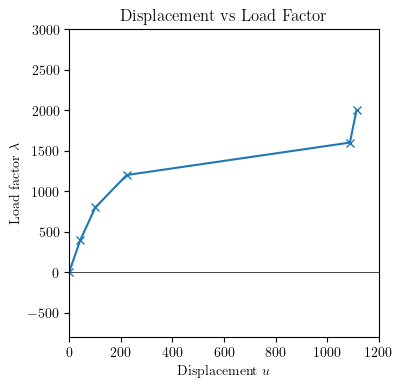

In [6]:
ax = create_figure()

x, y = analyze(*arch_model(), solution0, 6, 400.0)
ax.plot(-x, y, '-x', label="S0");

In [7]:
def solution1(model, dx):
    Jd = 5
    Jmax = 15
    model.integrator("LoadControl", dx, Jd, -800., 800.)


   FAILURE :: Iter:    25, Norm:     304.428, Norm deltaR:     75519.7
   FAILURE :: Iter:    25, Norm:      2055.3, Norm deltaR: 1.05669e+07
   FAILURE :: Iter:    25, Norm:     166.198, Norm deltaR:     22447.3
   FAILURE :: Iter:    25, Norm:     376.288, Norm deltaR:     22198.1
   FAILURE :: Iter:    25, Norm:     1090.83, Norm deltaR:      964889
   FAILURE :: Iter:    25, Norm:     14.4356, Norm deltaR:     49.4994
   FAILURE :: Iter:    25, Norm:      13.119, Norm deltaR:     48.8774
   FAILURE :: Iter:    25, Norm:     42.3986, Norm deltaR:     928.461
   FAILURE :: Iter:    25, Norm:      19.844, Norm deltaR:     102.553
   FAILURE :: Iter:    25, Norm:     19.7178, Norm deltaR:     102.501
   FAILURE :: Iter:    25, Norm:     7.83262, Norm deltaR:     16.0686
   FAILURE :: Iter:    25, Norm:     6.16819, Norm deltaR:     10.1236
   FAILURE :: Iter:    25, Norm:     5.37315, Norm deltaR:     7.18912
   FAILURE :: Iter:    25, Norm:     4.90937, Norm deltaR:     6.62558
   FAI

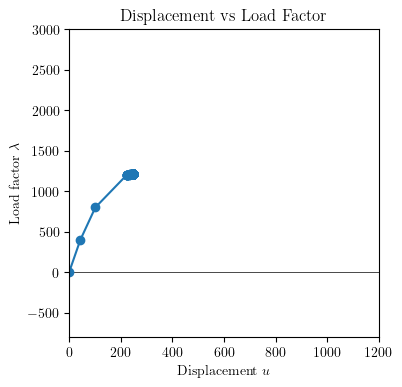

In [8]:
ax = create_figure()
x, y = analyze(*arch_model(), solution1, None, 400.0)
ax.plot(-x, y, '-o', label="S1")

### Displacement Control

In [9]:

def solution2(model,  dx, mid, dof, dumin=None, dumax=None):
    Jd  = 5
    if dumin is not None:
        model.integrator("DisplacementControl", mid, dof, dx, Jd, dumin, dumax)
    else:
        model.integrator("DisplacementControl", mid, dof, dx, Jd)



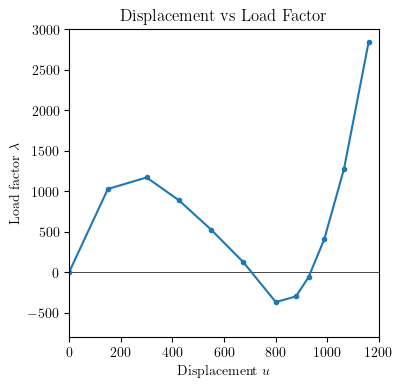

In [10]:
ax = create_figure()
model, mid = arch_model()
x, y = analyze(model, mid, solution2,    7, -150, *(mid, 2, -300, -10))
ax.plot(-x, y, '.-', label="S2")


### 3) ArcLength

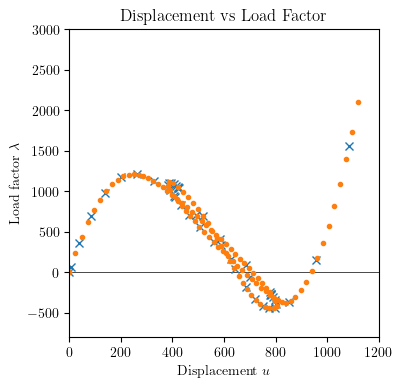

In [11]:
ax = create_figure()

def arc_control(model, dx, *args,  a=0):
    model.integrator("ArcLength", dx, a, j=6,det=True, exp=0.5, reference="point")

x, y = analyze(*arch_model(), arc_control, None,  30)
ax.plot(-x, y, "x", label="arc")


def arc_control(model, dx, *args,  a=0):
    model.integrator("ArcLength", dx, a, det=True, exp=0.0, reference="point")

x, y = analyze(*arch_model(), arc_control, None,  45)
ax.plot(-x, y, ".", label="arc")



### 4) MinUnbalDispNorm

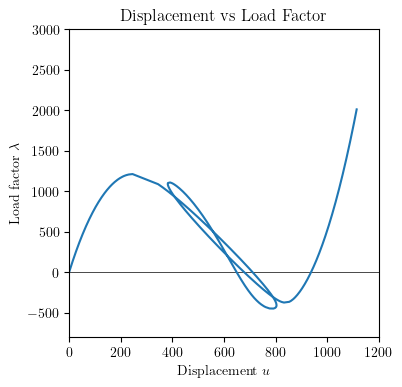

In [12]:
def norm_control(model, dx, *args):
    Jd  = 5
    # model.integrator("MinUnbalDispNorm",  dx, Jd, -15, 10, det=True)
    model.integrator("MinUnbalDispNorm",  dx, Jd, dx, dx, det=True)


ax = create_figure()
x, y = analyze(*arch_model(), norm_control,  None, 10)
ax.plot(-x, y, "-", label="norm")

### Other

   FAILURE :: Iter:    25, Norm:     304.428, Norm deltaR:     75519.7
   FAILURE :: Iter:    25, Norm:      2055.3, Norm deltaR: 1.05669e+07
   FAILURE :: Iter:    25, Norm:     166.198, Norm deltaR:     22447.3
   FAILURE :: Iter:    25, Norm:     376.288, Norm deltaR:     22198.1
   FAILURE :: Iter:    25, Norm:     1090.83, Norm deltaR:      964889
   FAILURE :: Iter:    25, Norm:     14.4356, Norm deltaR:     49.4994
   FAILURE :: Iter:    25, Norm:      13.119, Norm deltaR:     48.8774
   FAILURE :: Iter:    25, Norm:     42.3986, Norm deltaR:     928.461
   FAILURE :: Iter:    25, Norm:      19.844, Norm deltaR:     102.553
   FAILURE :: Iter:    25, Norm:     19.7178, Norm deltaR:     102.501
   FAILURE :: Iter:    25, Norm:     7.83262, Norm deltaR:     16.0686
   FAILURE :: Iter:    25, Norm:     6.16819, Norm deltaR:     10.1236
   FAILURE :: Iter:    25, Norm:     5.37315, Norm deltaR:     7.18912
   FAILURE :: Iter:    25, Norm:     4.90937, Norm deltaR:     6.62558
   FAI

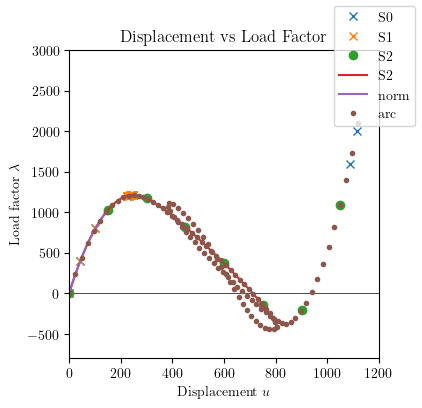

In [13]:
ax = create_figure()
fig = ax.figure

x, y = analyze(*arch_model(), solution0, 6, 400.0)
ax.plot(-x, y, 'x', label="S0")

x, y = analyze(*arch_model(), solution1, 6, 400.0)
ax.plot(-x, y, 'x', label="S1")


model, mid = arch_model()
x, y = analyze(model, mid, solution2,    7, -150, *(mid, 2))
ax.plot(-x, y, 'o', label="S2")

x, y = analyze(*arch_model(), solution2,  536, -1.5, *(mid, 2))
ax.plot(-x, y, '-', label="S2")

# x, y = analyze(*arch_model(), arc_control, 9500, 0.5, 0)
# ax.plot(-x, y, "-", label="arc")


x, y = analyze(*arch_model(), norm_control,  7000, 1.0)
ax.plot(-x, y, "-", label="norm")

x, y = analyze(*arch_model(), arc_control, None,  45)
ax.plot(-x, y, ".", label="arc")

# x, y = analyze(*arch_model(), arc_control,  80,  88, 0)
# ax.plot(-x, y, "+", label="arc")

# x, y = analyze(*arch_model(), arc_control,  80, 188, 0)
# ax.plot(-x, y, "*", label="arc")

# x, y = analyze(*arch_model(), arc_control, 8000, 0.8, 0)
# ax.plot(-x, y, "x", label="arc")



fig.legend();

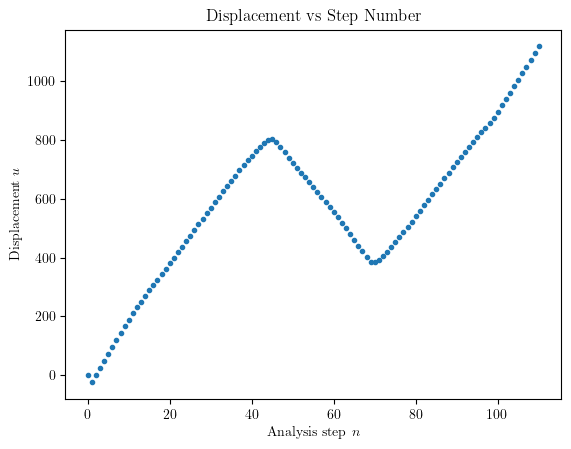

In [14]:
fix, ax = plt.subplots()
ax.plot(-x, '.');
ax.set_title("Displacement vs Step Number")
ax.set_ylabel("Displacement $u$")
ax.set_xlabel("Analysis step $n$");

<!-- <img src="arch.gif" width="80%"> -->

## References


- Clarke, M.J. and Hancock, G.J. (1990) ‘A study of incremental‐iterative strategies for non‐linear analyses’, International Journal for Numerical Methods in Engineering, 29(7), pp. 1365–1391. Available at: https://doi.org/10.1002/nme.1620290702.
